In [27]:
#we need a function extract_metadata to extract the metadata from the text files such as gender, party_list, titulaire_soutien

import re

def extract_metadata(text):
    metadata = {}

    text_upper = text.upper()

    #year
    year_match = re.search(r"(19\d{2})", text)
    metadata["year"] = year_match.group(1) if year_match else None

    #type of election
    if "LÉGISLATIVES" in text_upper or "LEGISLATIVES" in text_upper:
        metadata["type_election"] = "legislatives"
    elif "PRÉSIDENTIELLE" in text_upper or "PRESIDENTIELLE" in text_upper:
        metadata["type_election"] = "presidentielle"
    else:
        metadata["type_election"] = None

    #taking the name of the candidate
    name_match = re.search(r"\n([A-ZÉÈÀÙÂÊÎÔÛÄËÏÖÜÇ\- ]{5,})\n", text)
    candidate = name_match.group(1).strip() if name_match else None
    metadata["candidate"] = candidate

    #we find the gender by bruteforce on the first name (we can improve this later by using a more complete list of names or a library
    def guess_gender(name):
        if not name:
            return None
        first_name = name.split()[0].lower()

        # heuristique simple (à enrichir si besoin)
        male_names = {"jean", "paul", "pierre", "michel", "jacques"}
        female_names = {"marie", "anne", "francoise", "monique"}

        if first_name in male_names:
            return "male"
        elif first_name in female_names:
            return "female"
        else:
            return "unknown"

    metadata["gender"] = guess_gender(candidate)

    #party_list (we look for the first line in uppercase that is not the candidate name and has at least 8 characters)
    party_match = re.search(r"\n([A-ZÉÈÀÙÂÊÎÔÛÄËÏÖÜÇ \-']{8,})\n", text)
    metadata["party_list"] = party_match.group(1).strip() if party_match else None

    #titulaire_soutien (investi par, soutenu par, candidat de, avec le soutien de)
    support_match = re.search(
        r"(investi par|soutenu par|candidat de|avec le soutien de)(.+)",
        text,
        re.IGNORECASE
    )

    if support_match:
        metadata["titulaire_soutien"] = support_match.group(2).strip()
    else:
        metadata["titulaire_soutien"] = None

    return metadata

In [29]:
from pathlib import Path
import pandas as pd


def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâéèêîôûç0-9 ]", " ", text)
    return text


#we create the dataframe and extract columns gender, titulaire_soutien, party_list
data = []

base_path = Path("text_files")

for year in base_path.iterdir():
    for election in year.iterdir():
        for file in election.glob("*.txt"):
            text = file.read_text()
            text = clean_text(text)
            meta = extract_metadata(text)

            data.append({
                "text": text,
                "filename": file.stem,
                **meta
            })

df = pd.DataFrame(data)
print(df.shape)
print(df.head())

(21697, 8)
                                                text  \
0  sciences po   fonds cevipof élections législat...   
1  sciences po   fonds cevipof élections législat...   
2  sciences po   fonds cevipof république françai...   
3    elections legislatives de mars 1978 7  circo...   
4  an ekolojisted a sav o mouez     evid ma ne vi...   

                         filename  year type_election candidate gender  \
0  EL104_L_1978_03_050_03_2_PF_02  1978  legislatives      None   None   
1  EL102_L_1978_03_002_03_1_PF_03  1978  legislatives      None   None   
2  EL107_L_1978_03_092_13_1_PF_12  1978  legislatives      None   None   
3  EL104_L_1978_03_057_07_1_PF_06  1978  legislatives      None   None   
4  EL103_L_1978_03_029_04_1_PF_09  1947           NaN      None   None   

  party_list                                  titulaire_soutien  
0       None                                                NaN  
1       None                                                NaN  
2       N

<Axes: xlabel='length', ylabel='Count'>

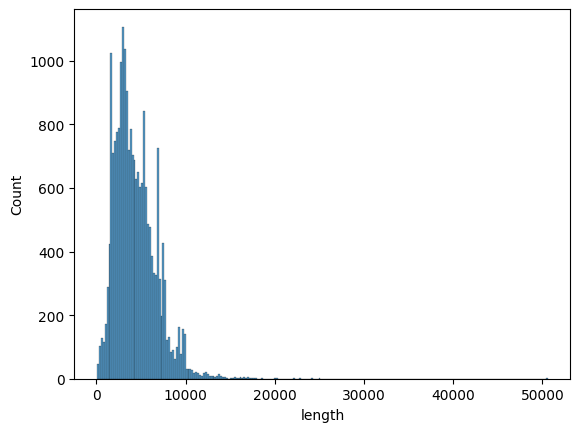

In [20]:
import seaborn as sns

#we visualize the distribution of text lengths
df["length"] = df["text"].apply(len)
sns.histplot(df["length"])

In [23]:
#detecting gender style
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["gender"], test_size=0.3
)

vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


clf = LogisticRegression()
clf.fit(X_train_vec, y_train)
print("Accuracy:", clf.score(X_test_vec, y_test))

KeyError: 'gender'

In [24]:
#detecting party style

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["party_list"], test_size=0.2
)

vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

KeyError: 'party_list'

In [25]:
#same for TfidfVectorizer instead of CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

NameError: name 'X_train' is not defined

In [26]:
#creating confusion matrix

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

NameError: name 'X_test_vec' is not defined